In [1]:
''' Surf dens corrected'''
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import util
import util_with_inter
from jax import numpy as jnp
from importlib import reload
import re

# Plot-Formatierung
plt.rcParams['font.size'] = 24.0
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = 'Arial'
plt.rcParams['font.weight'] = 'bold'
plt.rcParams['axes.labelsize'] = 'medium'
plt.rcParams['axes.labelweight'] = 'bold'
plt.rcParams['axes.linewidth'] = 1.2
plt.rcParams['lines.linewidth'] = 2.0

In [2]:
reload(util)
reload(util_with_inter)

''' Parameter for the model '''
rho_dm = 0.025
rhos = jnp.array([0.021, 0.016, 0.012, 0.0009, 0.0006, 0.0031, 0.0015, 0.0020, 0.0022, 0.007, 0.0135, 0.006, 0.002, 0.0035, 0.0001])
sigmas = jnp.array([4., 7., 9., 40., 20., 7.5, 10.5, 14., 18., 18.5, 18.5, 20., 20., 37., 100.])
erhos = jnp.array([0.5, 0.5, 0.5, 0.5, 0.2, 0.2, 0.2, 0.2, 0.2, 0.2, 0.2, 0.2, 0.2, 0.2, 0.2]) * rhos
esigmas = jnp.array([1., 1., 1., 1., 2., 2., 2., 2., 2., 2., 2., 5., 5., 5., 10.])
params = jnp.transpose(jnp.vstack((rhos, sigmas)))

In [9]:
def bounds(mean, std):
    mu = jnp.log(mean)-0.5*jnp.log((std/mean)**2+1)
    sigma = jnp.sqrt(jnp.log((std/mean)**2+1))
    mu_ = jnp.exp(mu)
    sigma_ = jnp.exp(sigma)
    return mu_/sigma_, mu_*sigma_

def extract_values(s):
    test_match = re.search(r'(5\*+lh_sd|1/4 \w+)', s)
    z2_match = re.search(r'z2:(\d+\.?\d*)', s)
    z1_match = re.search(r'z1:(\d+\.?\d*)', s)
    norm_match = re.search(r'norm:(\w+)', s)
    pn_match = re.search(r'data:(\w+)', s)
    
    test_value = test_match.group(1) if test_match else None
    z2_value = float(z2_match.group(1)) if z2_match else None
    z1_value = float(z1_match.group(1)) if z1_match else None
    norm_value = norm_match.group(1) if norm_match else None
    pn_value = pn_match.group(1) if pn_match else None
    
    return test_value, z2_value, z1_value, norm_value, pn_value

def find_row_index(file_path, test_target, z2_target, z1_target, norm_target, pn_target):
    with open(file_path, 'r') as file:
        for i, line in enumerate(file):
            test_value, z2_value, z1_value, norm_value, pn_value = extract_values(line)
            if test_value == test_target and z2_value == z2_target and z1_value == z1_target and norm_value == norm_target and pn_value == pn_target:
                index = i
                break
    
    return index

def read_res(file_rho, file_rd, file_sigma, file_sd):
    rho = jnp.array(pd.read_csv(file_rho, header=None).iloc[:,1])
    erho = jnp.array(pd.read_csv(file_rho, header=None).iloc[:,2])
    rd = jnp.array(pd.read_csv(file_rd, header=None).iloc[:,1])
    erd = jnp.array(pd.read_csv(file_rd, header=None).iloc[:,2])
    sigma = jnp.array(pd.read_csv(file_sigma, header=None).iloc[:,1])
    esigma = jnp.array(pd.read_csv(file_sigma, header=None).iloc[:,2])
    sd = jnp.array(pd.read_csv(file_sd, header=None).iloc[:,1])
    esd = jnp.array(pd.read_csv(file_sd, header=None).iloc[:,2])
    param = jnp.column_stack((rho, sigma))
    return rho, erho, rd, erd, sigma, esigma, sd, esd, param

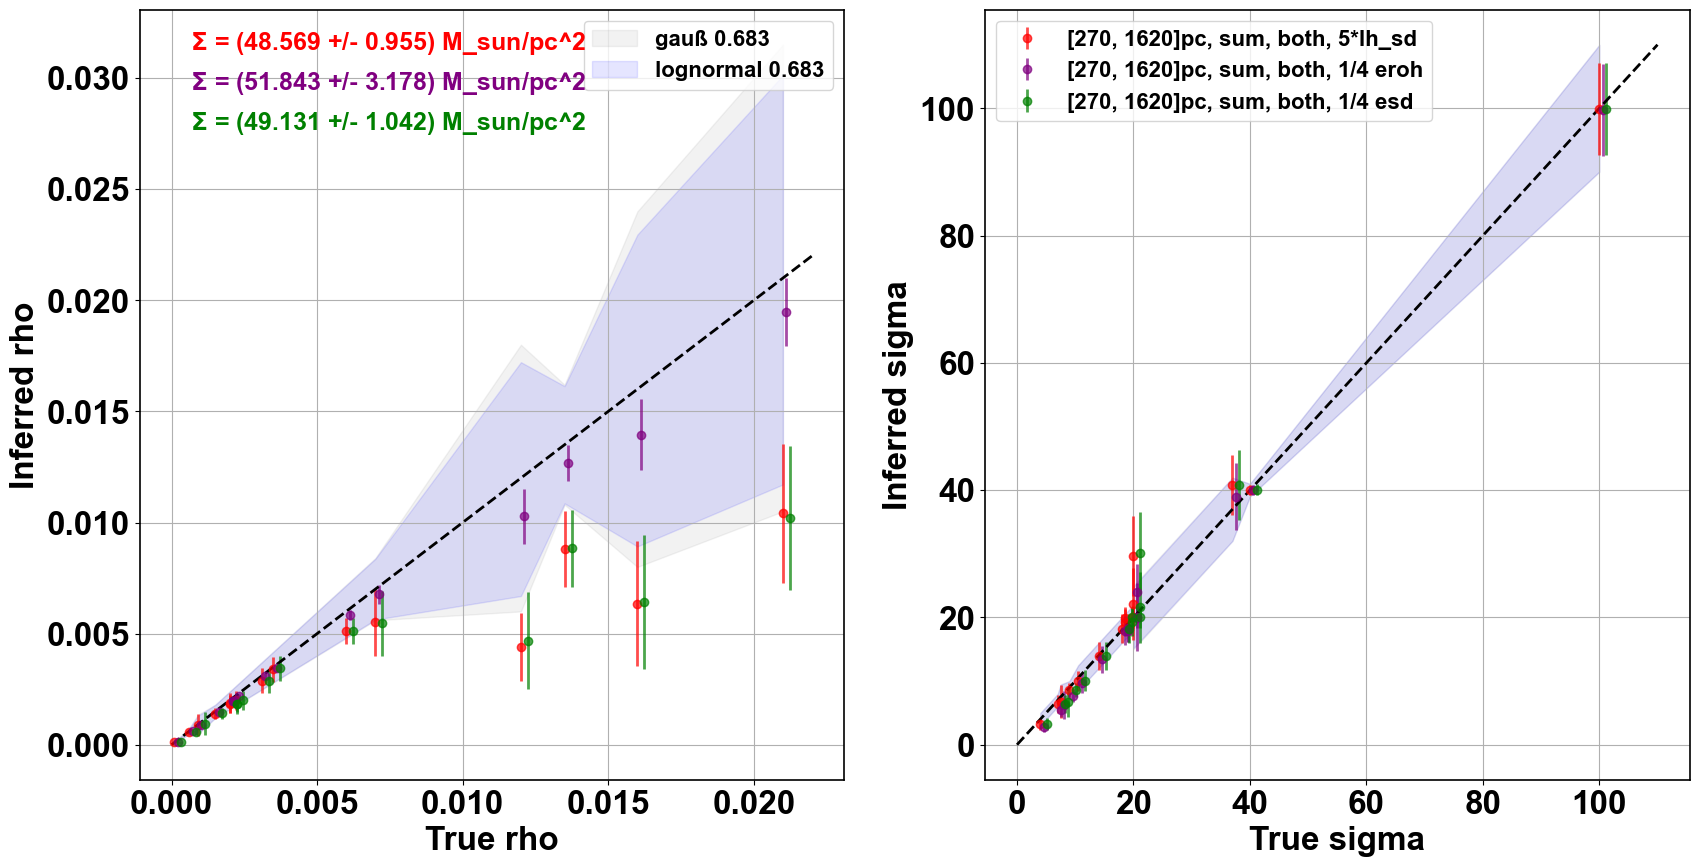

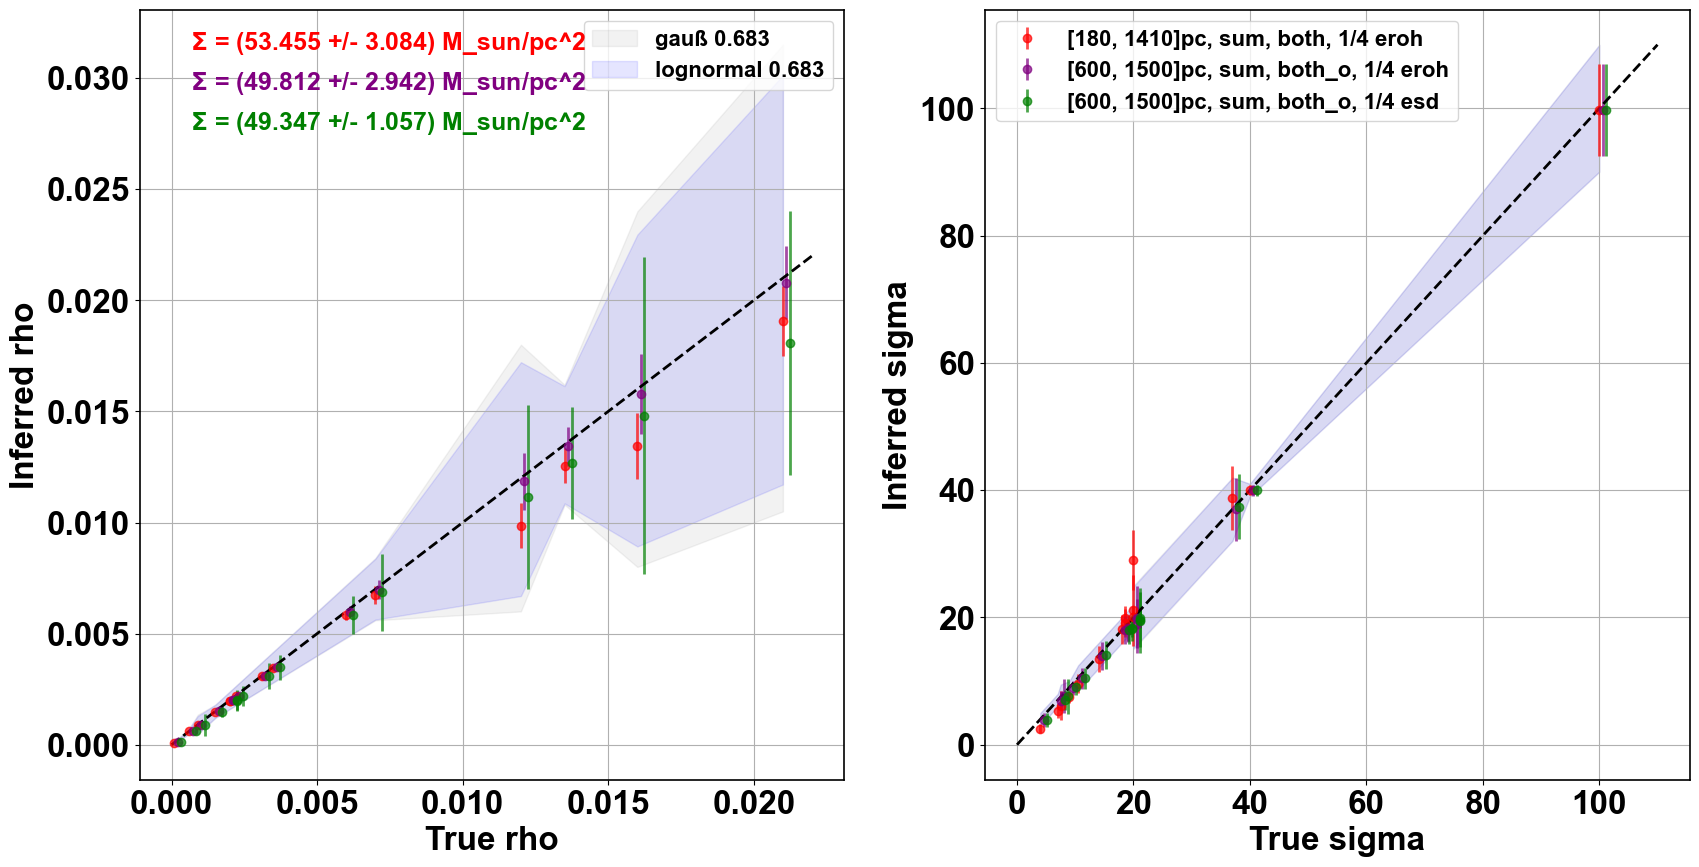

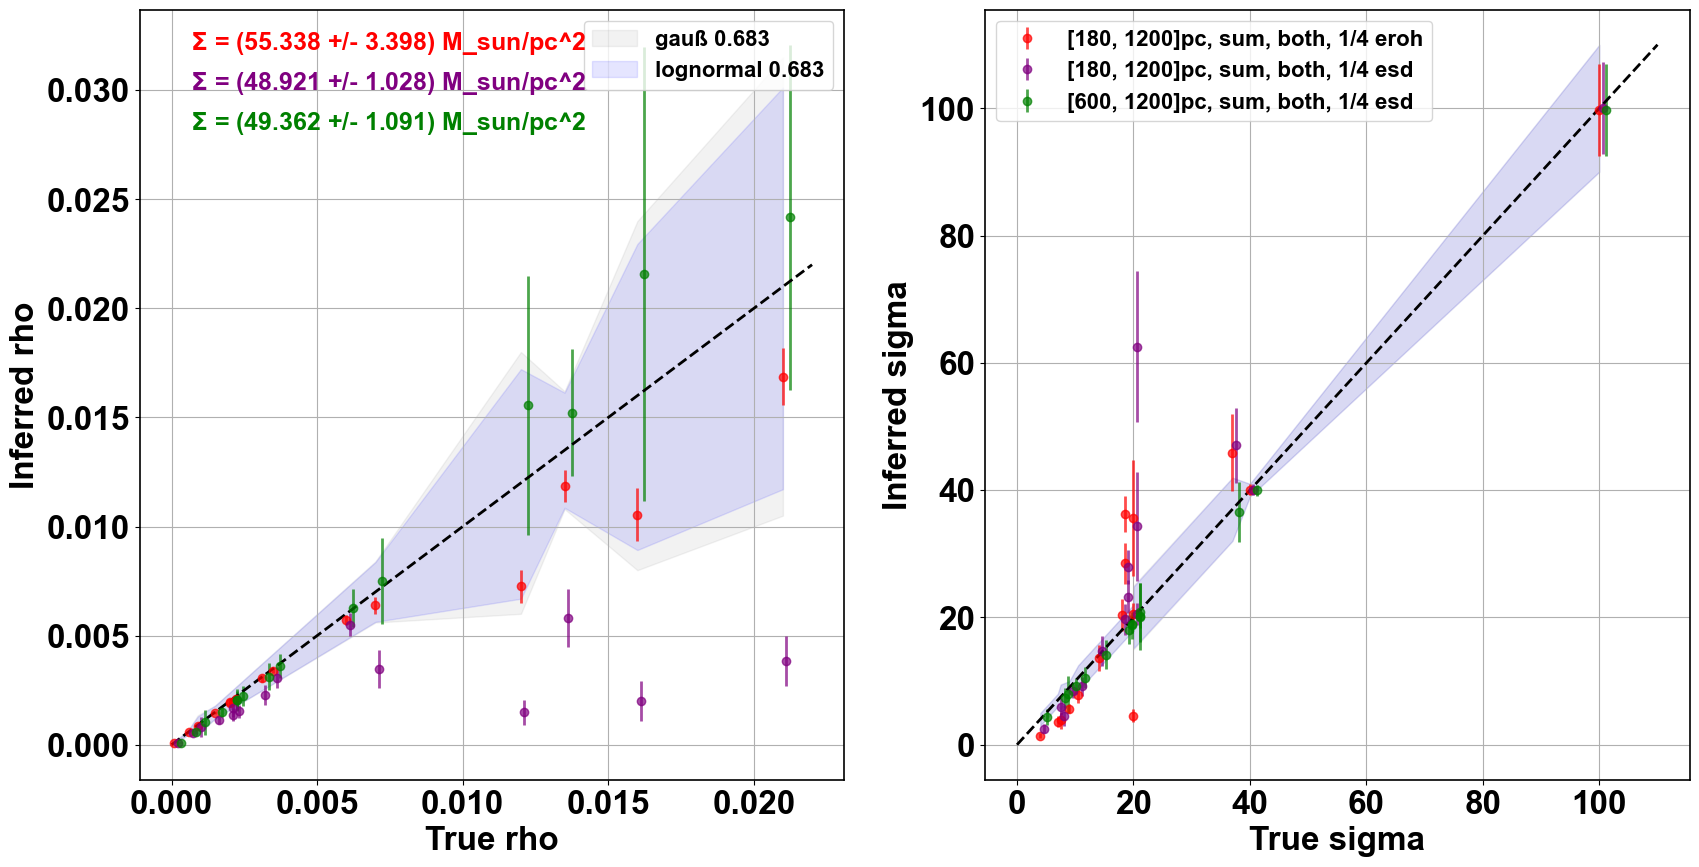

In [18]:
def plot_params(am_min, am_max, include):
    ''' Parameter for the model '''
    rho, erho, rd, erd, sigma, esigma, sd, esd, param = read_res(f'real data test/rho_{am_min:.0f}{am_max:.0f}.csv', f'real data test/rd_{am_min:.0f}{am_max:.0f}.csv', f'real data test/sigma_{am_min:.0f}{am_max:.0f}.csv', f'real data test/sd_{am_min:.0f}{am_max:.0f}.csv')

    ''' Visualisation '''
    fig, ax = plt.subplots(1, 2, figsize=(20, 10))
    colors = ['red', 'purple', 'green', 'orange', 'blue', 'black', 'brown', 'pink', 'gray', 'yellow', 'cyan', 'magenta', 'olive', 'lime', 'teal']

    for set in include:
        i = find_row_index(f'real data test/rd_{am_min:.0f}{am_max:.0f}.csv', set[0], set[1], set[2], set[3], set[4])
        ax[0].errorbar(rhos+i*0.00012, rho[i*15:(i+1)*15], yerr=erho[i*15:(i+1)*15], fmt='o', alpha=0.7, color = colors[i])
        ax[1].errorbar(sigmas+i*0.6, sigma[i*15:(i+1)*15], yerr=esigma[i*15:(i+1)*15], fmt='o', label=f'[{set[1]:.0f}, {set[2]:.0f}]pc, {set[3]}, {set[4]}, {set[0]}', alpha=0.7, color = colors[i])
        plt.figtext(0.15, 0.84-i*0.04, f'$\Sigma$ = ({sd[i]:.3f} +/- {esd[i]:.3f}) M_sun/pc^2', fontsize=18, color = colors[i])

    ax[0].plot([0, 0.022], [0, 0.022], color='black', linestyle='--')
    rho_sorted = np.argsort(rhos)
    ax[0].fill_between(rhos[rho_sorted], (rhos+erhos)[rho_sorted], y2=(rhos-erhos)[rho_sorted], alpha=0.1, color='gray', label='gauß 0.683')
    ax[0].fill_between(rhos[rho_sorted], bounds(rhos[rho_sorted], erhos[rho_sorted])[0], y2=bounds(rhos[rho_sorted], erhos[rho_sorted])[1], alpha=0.1, color='blue', label='lognormal 0.683')
    ax[0].set_xlabel("True rho")
    ax[0].set_ylabel("Inferred rho")
    ax[0].grid()
    ax[0].legend(fontsize='16')

    ax[1].plot([0, 110], [0, 110], color='black', linestyle='--')
    sigma_sorted = np.argsort(sigmas)
    ax[1].fill_between(sigmas[sigma_sorted], (sigmas+esigmas)[sigma_sorted], y2=(sigmas-esigmas)[sigma_sorted], alpha=0.1, color='gray')
    ax[1].fill_between(sigmas[sigma_sorted], bounds(sigmas[sigma_sorted], esigmas[sigma_sorted])[0], y2=bounds(sigmas[sigma_sorted], esigmas[sigma_sorted])[1], alpha=0.1, color='blue')
    ax[1].set_xlabel("True sigma")
    ax[1].set_ylabel("Inferred sigma")
    ax[1].grid()
    ax[1].legend(fontsize='16')
    plt.show()

plot_params(5, 6, [['5*lh_sd', 270, 1620, 'sum', 'both'], ['1/4 eroh', 270, 1620, 'sum', 'both'], ['1/4 esd', 270, 1620, 'sum', 'both']])
plot_params(6, 7, [['1/4 eroh', 180, 1410, 'sum', 'both'], ['1/4 eroh', 600, 1500, 'sum', 'both_o'], ['1/4 esd', 600, 1500, 'sum', 'both_o']])
plot_params(7, 8, [['1/4 eroh', 180, 1200, 'sum', 'both'], ['1/4 esd', 180, 1200, 'sum', 'both'], ['1/4 esd', 600, 1200, 'sum', 'both']])

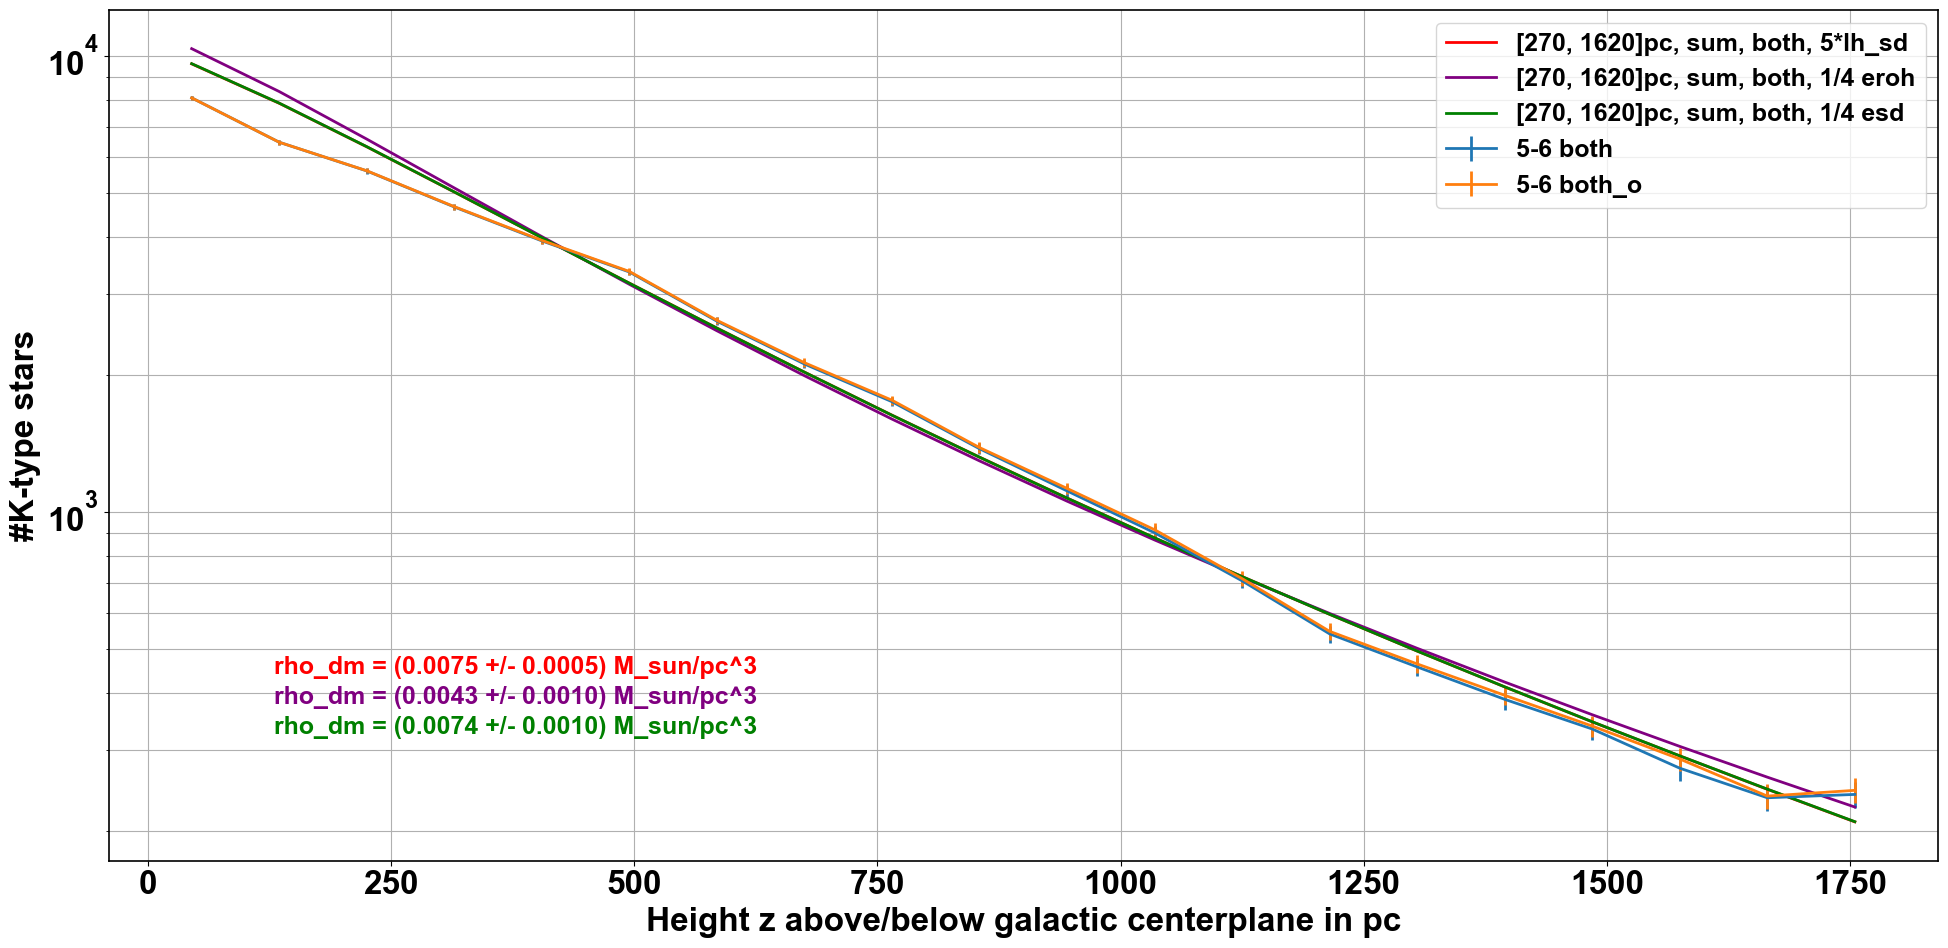

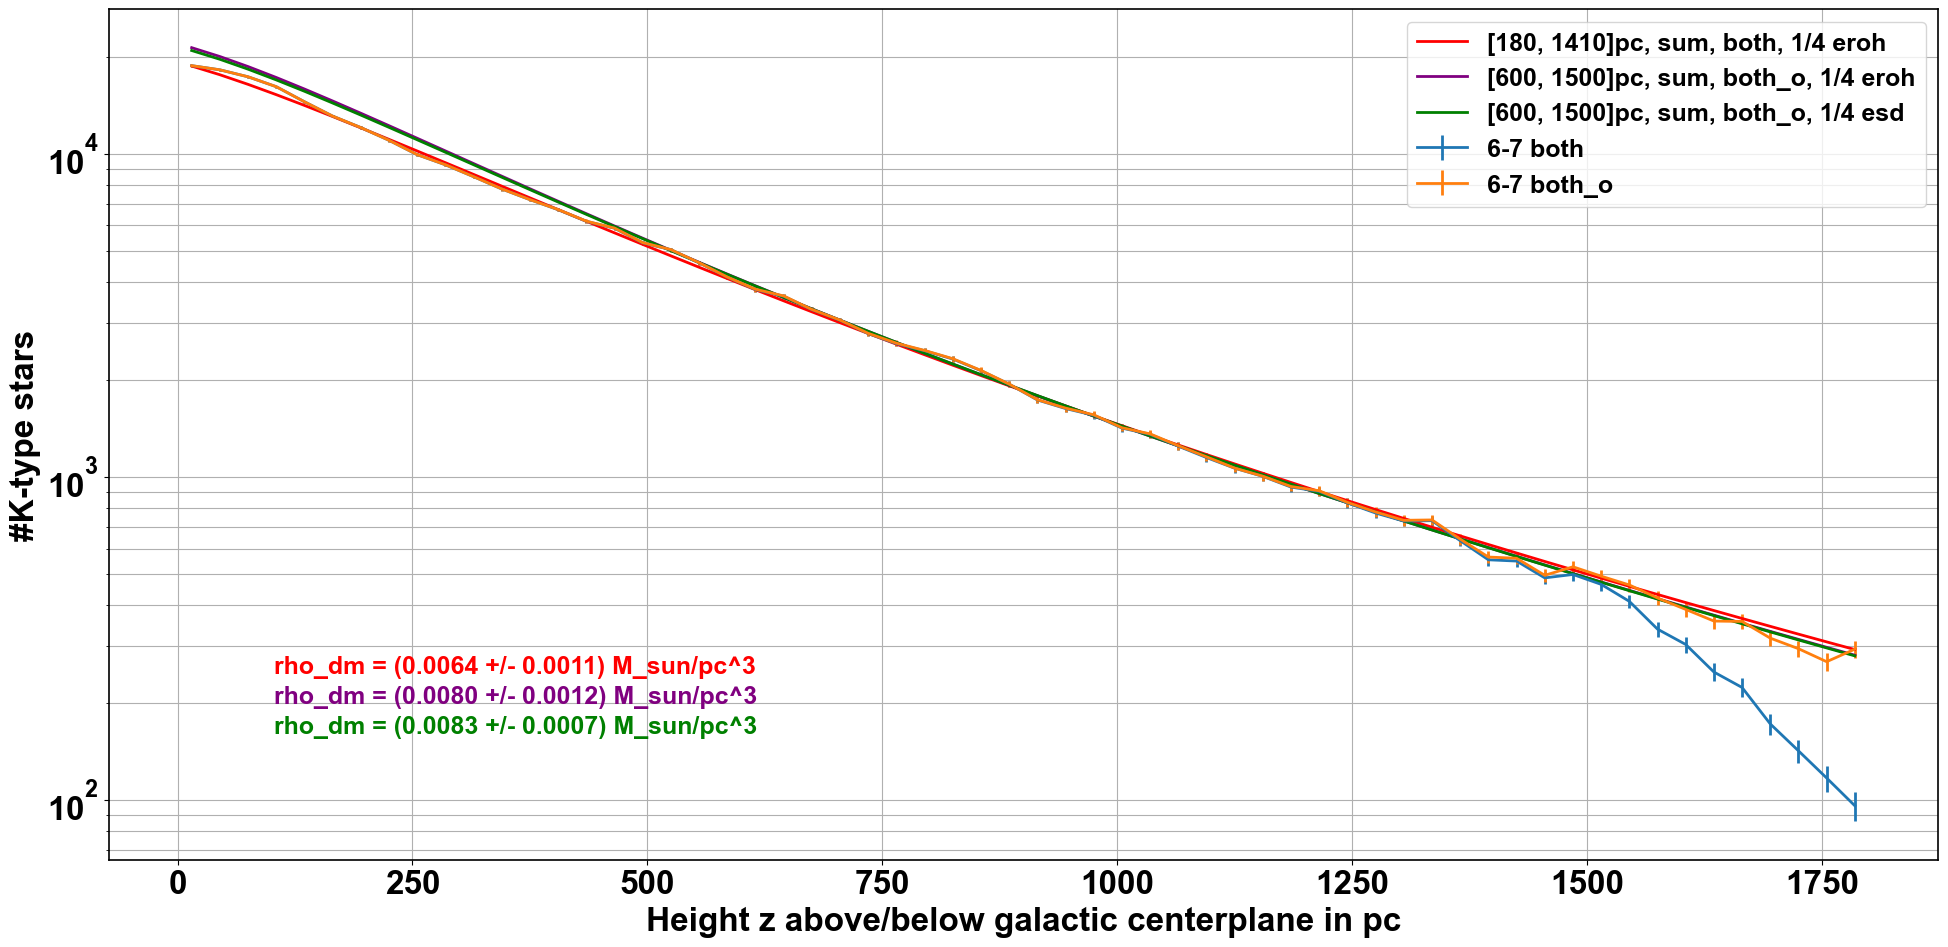

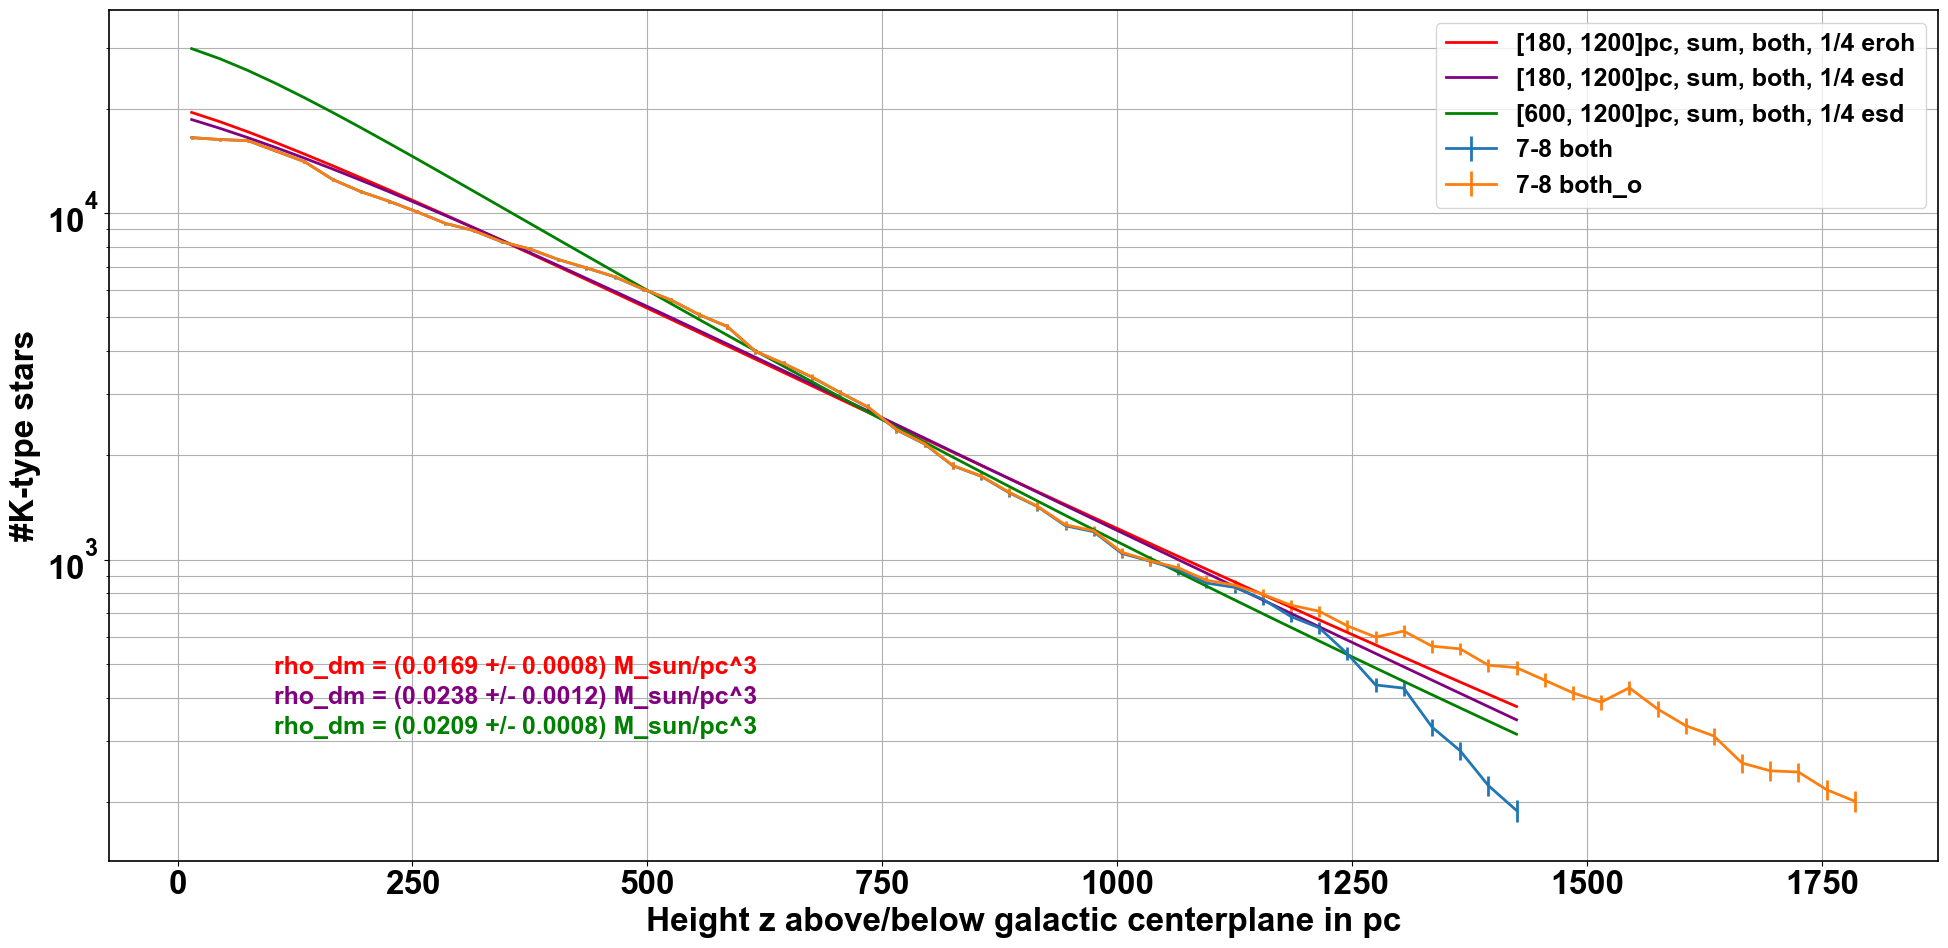

In [19]:
reload(util)

def plot_fits(am_min, am_max, include):
    ''' real data '''
    n_real = np.loadtxt(f'real data/n_{am_min}{am_max}.txt')
    bins = np.loadtxt(f'real data/bins_{am_min}{am_max}.txt')
    zz_real = (bins[1:]+bins[:-1])/2
    pos = np.where(zz_real >= 0)
    neg = np.where(zz_real < 0)
    n_sum = (n_real[pos]+np.flip(n_real[neg]))

    n_real_o = np.loadtxt(f'real data/n_{am_min}{am_max}_o.txt')
    bins_o = np.loadtxt(f'real data/bins_{am_min}{am_max}_o.txt')
    zz_real_o = (bins_o[1:]+bins_o[:-1])/2
    pos_o = np.where(zz_real_o >= 0)
    neg_o = np.where(zz_real_o < 0)
    n_sum_o = (n_real_o[pos_o]+np.flip(n_real_o[neg_o]))

    ''' Domain '''
    z2 = 0.
    z1 = max(bins)
    poly = np.loadtxt(f'real data/poly_58.txt')
    i2 = np.where(bins<=z2)[0][-1]
    i1 = np.where(bins>=z1)[0][0]
    z2 = bins[i2]
    z1 = bins[i1]
    n = int(z1)+1
    n_bins = int(len(bins[i2:i1+1])-1)

    z2_o = 0.
    z1_o = max(bins_o)
    poly_o = np.loadtxt(f'real data/poly_58.txt')
    i2_o = np.where(bins_o<=z2_o)[0][-1]
    i1_o = np.where(bins_o>=z1_o)[0][0]
    z2_o = bins_o[i2_o]
    z1_o = bins_o[i1_o]
    n_o = int(z1_o)+1
    n_bins_o = int(len(bins_o[i2_o:i1_o+1])-1)

    ''' Parameter for the model '''
    rho, erho, rd, erd, sigma, esigma, sd, esd, param = read_res(f'real data test/rho_{am_min:.0f}{am_max:.0f}.csv', f'real data test/rd_{am_min:.0f}{am_max:.0f}.csv', f'real data test/sigma_{am_min:.0f}{am_max:.0f}.csv', f'real data test/sd_{am_min:.0f}{am_max:.0f}.csv')

    ''' Visualisation '''
    fig= plt.figure(figsize=(20,10))
    colors = ['red', 'purple', 'green', 'orange', 'blue', 'black', 'brown', 'pink', 'gray', 'yellow', 'cyan', 'magenta', 'olive', 'lime', 'teal']

    plt.errorbar(zz_real[pos], n_sum, yerr=np.sqrt(n_sum), label=f"{am_min}-{am_max} both")
    plt.errorbar(zz_real_o[pos_o], n_sum_o, yerr=np.sqrt(n_sum_o), label=f"{am_min}-{am_max} both_o")

    plt.yscale("log")
    plt.xlabel("Height z above/below galactic centerplane in pc")
    plt.ylabel("#K-type stars")

    for set in include:
        if set[4] == 'both':
            i2_ = np.where(bins == set[1])[0][0] - len(bins)//2
            i1_ = np.where(bins == set[2])[0][0] - len(bins)//2
        elif set[4] == 'both_o':
            i2_ = np.where(bins_o == set[1])[0][0] - len(bins_o)//2
            i1_ = np.where(bins_o == set[2])[0][0] - len(bins_o)//2
        i = find_row_index(f'real data test/rd_{am_min:.0f}{am_max:.0f}.csv', set[0], set[1], set[2], set[3], set[4])
    
        ''' calculated data'''
        if set[4] == 'both': 
            uz, zs = util.diffraxDopri5(rd[i], param[i*15:(i+1)*15], z1, n)
            vdfo_norm_calc, z = util.vdfo_norm(z2, z1, zs, uz, n, poly)
            integral, z_borders = util.binning(vdfo_norm_calc, z, z2, z1, n, n_bins)
        elif set[4] == 'both_o':
            uz, zs = util.diffraxDopri5(rd[i], param[i*15:(i+1)*15], z1_o, n_o)
            vdfo_norm_calc, z = util.vdfo_norm(z2_o, z1_o, zs, uz, n_o, poly_o)
            integral, z_borders = util.binning(vdfo_norm_calc, z, z2_o, z1_o, n_o, n_bins_o)
        if set[3] == 'sum':
            if set[4] == 'both':
                n_ = integral / sum(integral[i2_:i1_]) * sum(n_sum[i2_:i1_])
            elif set[4] == 'both_o':
                n_ = integral / sum(integral[i2_:i1_]) * sum(n_sum_o[i2_:i1_])
        else:
            n_ = integral / integral[i2_] * n_sum[i2_]
        zz = (z_borders[1:] + z_borders[:-1]) / 2

        plt.plot(zz, n_, label=f'[{set[1]:.0f}, {set[2]:.0f}]pc, {set[3]}, {set[4]}, {set[0]}', color=colors[i])
        plt.figtext(0.15, 0.3-i*0.03, f'rho_dm = ({rd[i]:.4f} +/- {erd[i]:.4f}) M_sun/pc^3', color=colors[i], fontsize=18)


    plt.legend(fontsize='18')
    plt.grid(which='both')
    plt.tight_layout()
    plt.show()

plot_fits(5, 6, [['5*lh_sd', 270, 1620, 'sum', 'both'], ['1/4 eroh', 270, 1620, 'sum', 'both'], ['1/4 esd', 270, 1620, 'sum', 'both']])
plot_fits(6, 7, [['1/4 eroh', 180, 1410, 'sum', 'both'], ['1/4 eroh', 600, 1500, 'sum', 'both_o'], ['1/4 esd', 600, 1500, 'sum', 'both_o']])
plot_fits(7, 8, [['1/4 eroh', 180, 1200, 'sum', 'both'], ['1/4 esd', 180, 1200, 'sum', 'both'], ['1/4 esd', 600, 1200, 'sum', 'both']])